# Analyse de la Régression Multiple 

## Importer les library et la Data

### Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data

In [2]:
df = pd.read_csv("E:/Documents/A/bakwetu/coccinelle/MASG_M2/Programme_de_cours/IA & Ecologie de maladie (Data sciences)/git_cours/INOHA-DataScience-M2/donnees_mpox_RDC_3000.csv",
                sep=";")
df

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,1,Mongala,206,24.4,0.480,64,39,31.8,150,22,1,4,29,Pluie,3478,19.33
1,OBS_00002,2,Kinshasa,56,23.7,0.474,74,107,24.9,300,5,1,6,42,Seche,3713,14.00
2,OBS_00003,3,Kinshasa,59,25.2,0.333,62,140,53.9,310,16,0,8,20,Seche,4833,6.45
3,OBS_00004,4,Mai-Ndombe,396,24.1,0.354,68,97,25.9,210,4,0,10,82,Pluie,3777,39.05
4,OBS_00005,5,Kasai,127,19.8,0.303,61,86,30.3,260,24,1,6,24,Pluie,9396,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,2996,Kongo Central,271,31.6,0.534,88,57,22.4,220,33,1,7,125,Pluie,3166,56.82
2996,OBS_02997,2997,Sud-Ubangi,88,24.6,0.262,95,47,34.1,370,7,1,6,70,Seche,6099,18.92
2997,OBS_02998,2998,Bas-Uele,268,25.6,0.720,58,18,41.9,190,23,0,2,36,Pluie,5475,18.95
2998,OBS_02999,2999,Haut-Uele,211,24.9,0.196,77,28,10.6,370,2,0,2,160,Pluie,4813,43.24


## Analyse Exploratoire (EDA)

### Descriptive 

In [3]:
df.describe()

,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Population_Risque,Taux_Positivite_pct
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,157.779667,24.980367,0.451182,71.571667,119.100333,31.843967,286.143333,15.558333,0.40000,5.018000,79.603333,5471.297667,27.041943
std,866.169729,101.958774,3.832510,0.157799,11.625285,95.218460,14.079517,88.256194,15.139386,0.48998,1.954213,70.119799,2636.188129,20.156959
min,1.000000,2.000000,18.000000,0.103000,40.000000,5.000000,5.600000,90.000000,1.000000,0.00000,1.000000,0.000000,1001.000000,0.000000
25%,750.750000,77.000000,22.300000,0.331000,64.000000,48.000000,20.800000,220.000000,5.000000,0.00000,4.000000,29.000000,3127.000000,11.430000
50%,1500.500000,136.000000,24.900000,0.452000,71.500000,94.000000,30.400000,280.000000,11.000000,0.00000,5.000000,57.000000,5514.500000,21.455000
75%,2250.250000,221.000000,27.600000,0.576000,80.000000,163.000000,41.525000,340.000000,22.000000,1.00000,6.000000,109.000000,7819.250000,38.070000
max,3000.000000,400.000000,34.000000,0.795000,95.000000,500.000000,77.800000,800.000000,142.000000,1.00000,10.000000,479.000000,9997.000000,95.000000


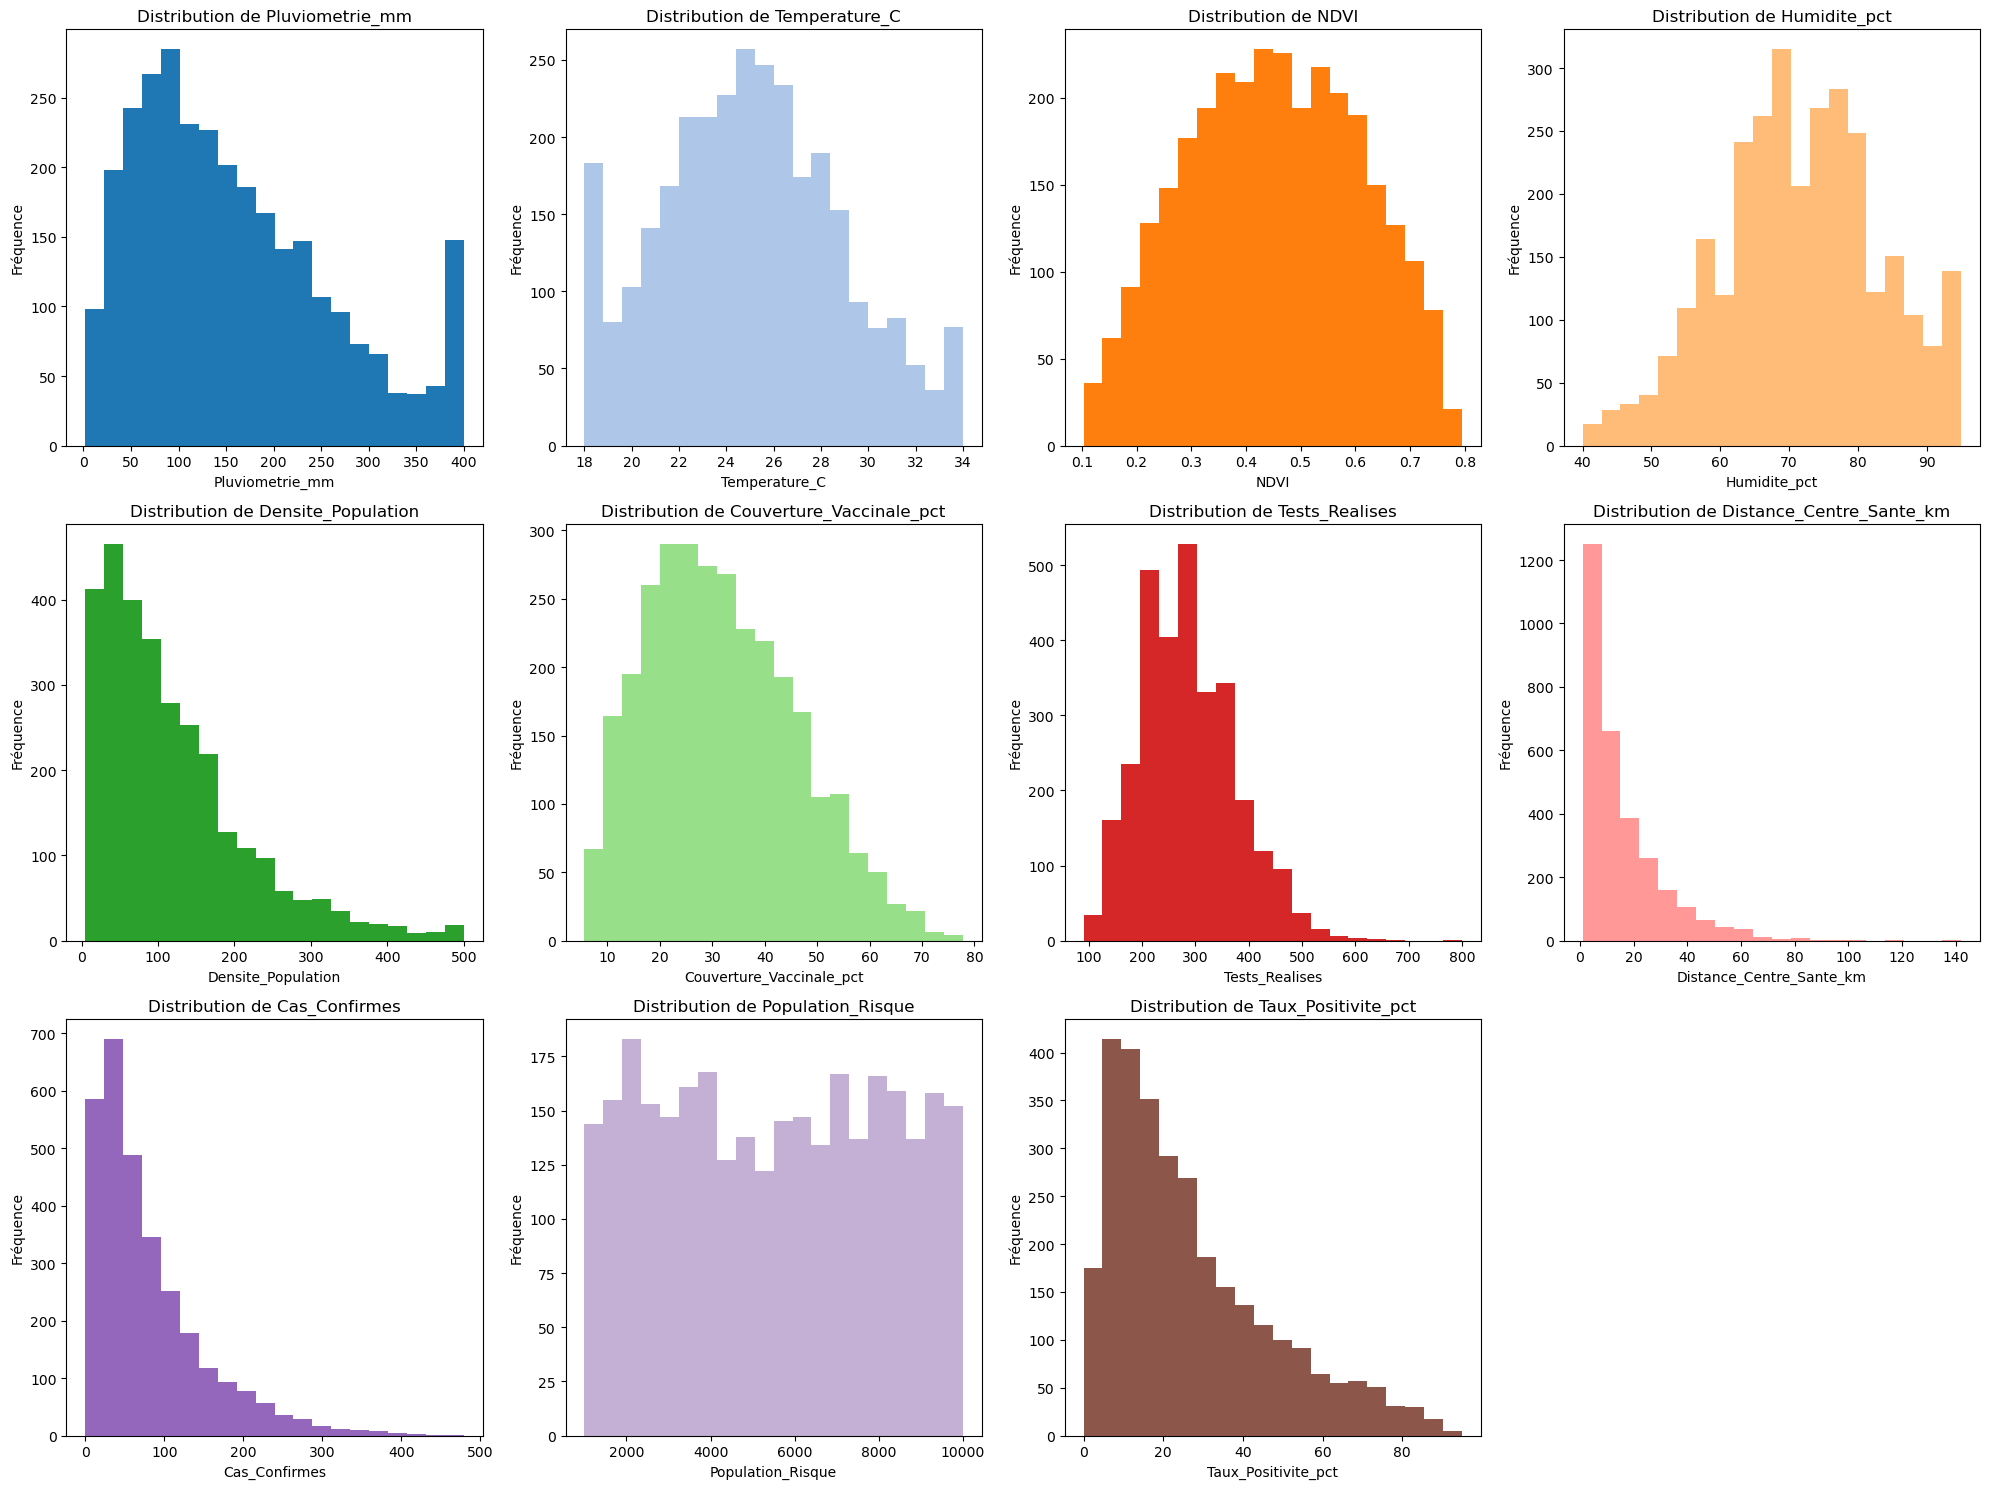

In [4]:
import matplotlib.pyplot as plt
import math

variables = [
    'Pluviometrie_mm',
    'Temperature_C',
    'NDVI',
    'Humidite_pct',
    'Densite_Population',
    'Couverture_Vaccinale_pct',
    'Tests_Realises',
    'Distance_Centre_Sante_km',
    'Cas_Confirmes',
    'Population_Risque',
    'Taux_Positivite_pct'
]

n_cols = 4
n_rows = math.ceil(len(variables) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 5 * n_rows)
)

axes = axes.flatten()

couleurs = plt.cm.tab20(
    range(len(variables))
)

for i, var in enumerate(variables):

    if df[var].dtype == 'object':

        df[var].value_counts().plot(
            kind='bar',
            ax=axes[i],
            color=couleurs[i]
        )

        axes[i].set_title(
            f'Distribution de {var}'
        )

        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Effectif')
        axes[i].tick_params(
            axis='x',
            rotation=45
        )

    else:

        axes[i].hist(
            df[var].dropna(),
            bins=20,
            color=couleurs[i]
        )

        axes[i].set_title(
            f'Distribution de {var}'
        )

        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Fréquence')

for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    r'E:\Documents\A\bakwetu\coccinelle\MASG_M2\Programme_de_cours\IA & Ecologie de maladie (Data sciences)\git_cours\TP_RM\analyse_descriptive_variables.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Verifier les valeurs manquantes 

In [5]:
count = df.isnull().sum()
print(count)

ID                          0
Semaine                     0
Province                    0
Pluviometrie_mm             0
Temperature_C               0
NDVI                        0
Humidite_pct                0
Densite_Population          0
Couverture_Vaccinale_pct    0
Tests_Realises              0
Distance_Centre_Sante_km    0
Reservoirs_Animaux          0
Mobilite_Humaine            0
Cas_Confirmes               0
Saison                      0
Population_Risque           0
Taux_Positivite_pct         0
dtype: int64


### Separer les variables qualitative de quantitative

### Variables qualitatives 

In [6]:
df_quali = df.select_dtypes(include=["object"])
df_quali

,ID,Province,Saison
0,OBS_00001,Mongala,Pluie
1,OBS_00002,Kinshasa,Seche
2,OBS_00003,Kinshasa,Seche
3,OBS_00004,Mai-Ndombe,Pluie
4,OBS_00005,Kasai,Pluie
...,...,...,...
2995,OBS_02996,Kongo Central,Pluie
2996,OBS_02997,Sud-Ubangi,Seche
2997,OBS_02998,Bas-Uele,Pluie
2998,OBS_02999,Haut-Uele,Pluie


### Variables quantitatives

In [7]:
df_quanti = df.select_dtypes(include=["int","float"])
df_quanti

,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Population_Risque,Taux_Positivite_pct
0,1,206,24.4,0.480,64,39,31.8,150,22,1,4,29,3478,19.33
1,2,56,23.7,0.474,74,107,24.9,300,5,1,6,42,3713,14.00
2,3,59,25.2,0.333,62,140,53.9,310,16,0,8,20,4833,6.45
3,4,396,24.1,0.354,68,97,25.9,210,4,0,10,82,3777,39.05
4,5,127,19.8,0.303,61,86,30.3,260,24,1,6,24,9396,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,271,31.6,0.534,88,57,22.4,220,33,1,7,125,3166,56.82
2996,2997,88,24.6,0.262,95,47,34.1,370,7,1,6,70,6099,18.92
2997,2998,268,25.6,0.720,58,18,41.9,190,23,0,2,36,5475,18.95
2998,2999,211,24.9,0.196,77,28,10.6,370,2,0,2,160,4813,43.24


# Préparation du modèle

## Transformation des variales qualitatives en numerique

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

columns = ['Province', 'Saison']

for i in columns :
  df[i] = le.fit_transform(df[i])

In [9]:
df_quanti = df.select_dtypes(include=["int","float"])
df_quanti

,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,1,17,206,24.4,0.480,64,39,31.8,150,22,1,4,29,0,3478,19.33
1,2,9,56,23.7,0.474,74,107,24.9,300,5,1,6,42,1,3713,14.00
2,3,9,59,25.2,0.333,62,140,53.9,310,16,0,8,20,1,4833,6.45
3,4,15,396,24.1,0.354,68,97,25.9,210,4,0,10,82,0,3777,39.05
4,5,6,127,19.8,0.303,61,86,30.3,260,24,1,6,24,0,9396,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,10,271,31.6,0.534,88,57,22.4,220,33,1,7,125,0,3166,56.82
2996,2997,22,88,24.6,0.262,95,47,34.1,370,7,1,6,70,1,6099,18.92
2997,2998,0,268,25.6,0.720,58,18,41.9,190,23,0,2,36,0,5475,18.95
2998,2999,4,211,24.9,0.196,77,28,10.6,370,2,0,2,160,0,4813,43.24


### Test de corrélation 

In [11]:
from scipy.stats import pearsonr
import pandas as pd

correlation_results = []

variables = df_quanti.columns

for i in range(len(variables)):
    for j in range(i + 1, len(variables)):

        var1 = variables[i]
        var2 = variables[j]

        r, p_value = pearsonr(
            df_quanti[var1],
            df_quanti[var2]
        )

        correlation_results.append({
            'Variable_1': var1,
            'Variable_2': var2,
            'Correlation_r': r,
            'p_value': p_value
        })

correlation_df = pd.DataFrame(
    correlation_results
)

correlation_df.to_excel(
    "E:/Documents/A/bakwetu/coccinelle/MASG_M2/Programme_de_cours/IA & Ecologie de maladie (Data sciences)/git_cours/TP_RM/cor.xlsx",
    index=False
)

correlation_df

,Variable_1,Variable_2,Correlation_r,p_value
0,Semaine,Province,0.012871,4.809793e-01
1,Semaine,Pluviometrie_mm,0.021729,2.341286e-01
2,Semaine,Temperature_C,-0.003056,8.671045e-01
3,Semaine,NDVI,-0.008289,6.499706e-01
4,Semaine,Humidite_pct,-0.004408,8.092841e-01
...,...,...,...,...
115,Cas_Confirmes,Population_Risque,0.022979,2.082955e-01
116,Cas_Confirmes,Taux_Positivite_pct,0.899874,0.000000e+00
117,Saison,Population_Risque,-0.015343,4.008791e-01
118,Saison,Taux_Positivite_pct,-0.513103,3.501460e-201


#### Graphique

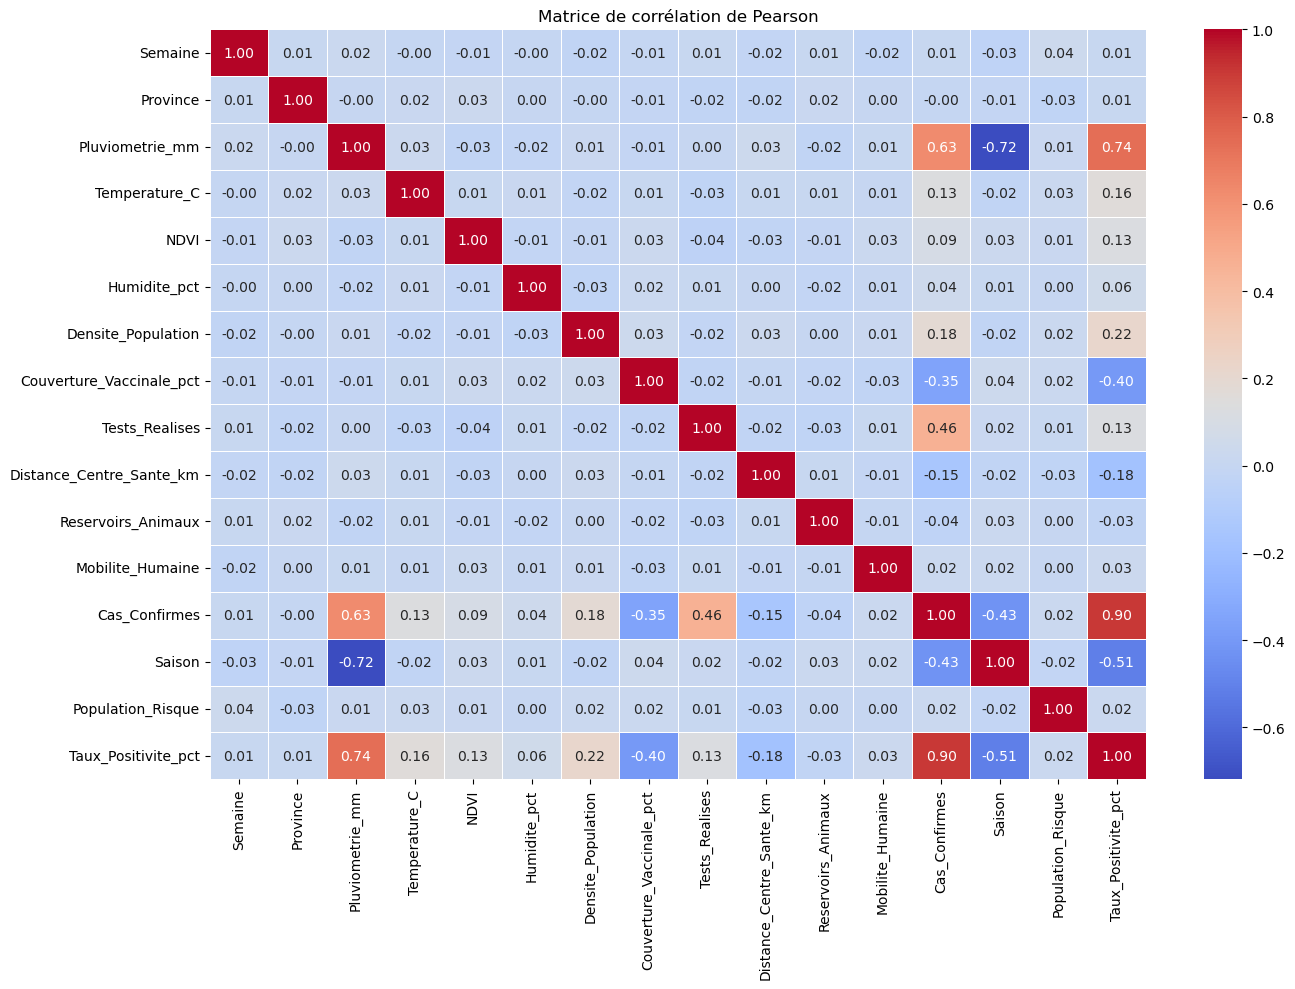

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_quanti.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Matrice de corrélation de Pearson')

plt.tight_layout()

plt.savefig(
    r'E:\Documents\A\bakwetu\coccinelle\MASG_M2\Programme_de_cours\IA & Ecologie de maladie (Data sciences)\git_cours\TP_RM\matrice_correlation.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Vif (Test de multi colinéarité)

In [13]:
variables_explicatives = [
    'Pluviometrie_mm',
    'Temperature_C',
    'NDVI',
    'Humidite_pct',
    'Densite_Population',
    'Couverture_Vaccinale_pct',
    'Tests_Realises',
    'Distance_Centre_Sante_km',
    'Reservoirs_Animaux',
    'Mobilite_Humaine',
    'Population_Risque'
]

X = df[variables_explicatives]

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()

vif_df['Variable'] = X.columns

vif_df['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_df

,Variable,VIF
0,Pluviometrie_mm,3.346267
1,Temperature_C,28.933584
2,NDVI,8.558944
3,Humidite_pct,27.012069
4,Densite_Population,2.533685
5,Couverture_Vaccinale_pct,5.931731
6,Tests_Realises,10.345143
7,Distance_Centre_Sante_km,2.044487
8,Reservoirs_Animaux,1.654700
9,Mobilite_Humaine,7.247617


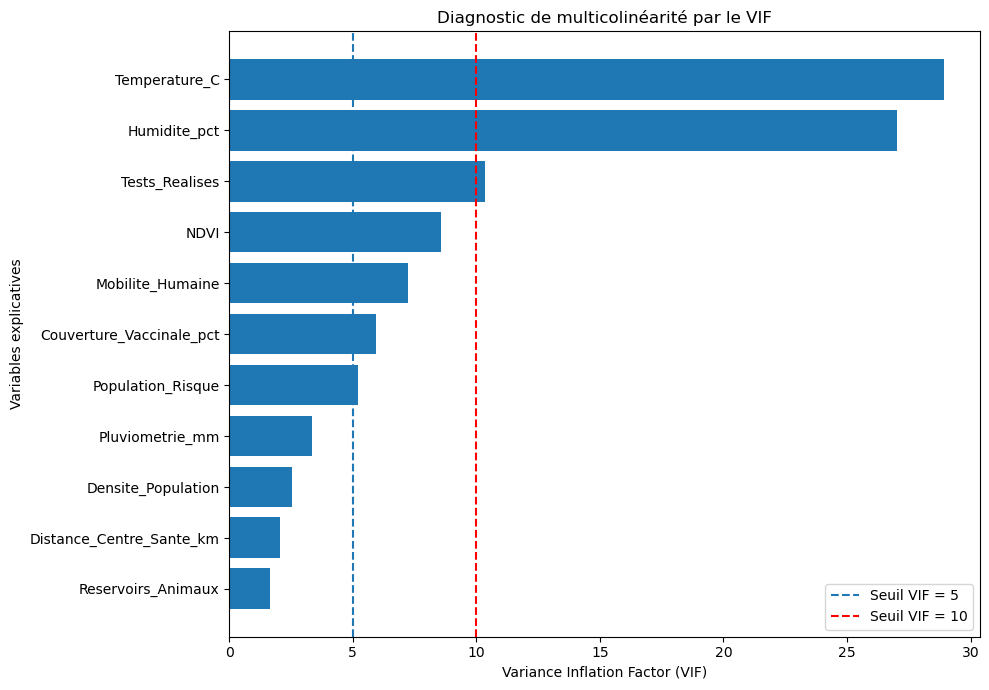

In [15]:
import matplotlib.pyplot as plt

vif_plot = vif_df.sort_values(
    by='VIF',
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    vif_plot['Variable'],
    vif_plot['VIF']
)

plt.axvline(
    x=5,
    linestyle='--',
    label='Seuil VIF = 5'
)

plt.axvline(
    x=10,
    linestyle='--',
    color='red',
    label='Seuil VIF = 10'
)

plt.xlabel('Variance Inflation Factor (VIF)')
plt.ylabel('Variables explicatives')
plt.title('Diagnostic de multicolinéarité par le VIF')

plt.legend()

plt.tight_layout()

plt.savefig(
    r'E:\Documents\A\bakwetu\coccinelle\MASG_M2\Programme_de_cours\IA & Ecologie de maladie (Data sciences)\git_cours\TP_RM\graphique_VIF.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Determiner X et Y

#### Normalisation

In [16]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
df_min = minmax.fit_transform(df_quanti)

df_scaler = pd.DataFrame(df_min, columns =df_quanti.columns)

df_scaler

,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,0.000000,0.68,0.512563,0.40000,0.544798,0.436364,0.068687,0.362881,0.084507,0.148936,1.0,0.333333,0.060543,0.0,0.275345,0.203474
1,0.000333,0.36,0.135678,0.35625,0.536127,0.618182,0.206061,0.267313,0.295775,0.028369,1.0,0.555556,0.087683,1.0,0.301467,0.147368
2,0.000667,0.36,0.143216,0.45000,0.332370,0.400000,0.272727,0.668975,0.309859,0.106383,0.0,0.777778,0.041754,1.0,0.425967,0.067895
3,0.001000,0.60,0.989950,0.38125,0.362717,0.509091,0.185859,0.281163,0.169014,0.021277,0.0,1.000000,0.171190,0.0,0.308582,0.411053
4,0.001334,0.24,0.314070,0.11250,0.289017,0.381818,0.163636,0.342105,0.239437,0.163121,1.0,0.555556,0.050104,0.0,0.933193,0.097158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.998666,0.40,0.675879,0.85000,0.622832,0.872727,0.105051,0.232687,0.183099,0.226950,1.0,0.666667,0.260960,0.0,0.240663,0.598105
2996,0.999000,0.88,0.216080,0.41250,0.229769,1.000000,0.084848,0.394737,0.394366,0.042553,1.0,0.555556,0.146138,1.0,0.566696,0.199158
2997,0.999333,0.00,0.668342,0.47500,0.891618,0.327273,0.026263,0.502770,0.140845,0.156028,0.0,0.111111,0.075157,0.0,0.497332,0.199474
2998,0.999667,0.16,0.525126,0.43125,0.134393,0.672727,0.046465,0.069252,0.394366,0.007092,0.0,0.111111,0.334029,0.0,0.423744,0.455158


#### Separer le Target des autres variables

In [17]:
X = df_scaler.drop('Cas_Confirmes', axis=1)
y = df_scaler['Cas_Confirmes']

# Entrainement du Modèle 

## Faire le split (Séparer les donnée d'entrainement et d'évaluation)

In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Entrainer le modèle

In [19]:
from sklearn.linear_model import LinearRegression

model_LRM = LinearRegression()
model_LRM.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Intercept 

In [20]:
bo = model_LRM.intercept_
bo

np.float64(-0.10893745248230474)

### Vérifier les coeficient des toutes les variables 

In [21]:
coef = model_LRM.coef_
coef

array([-1.97958161e-03, -5.79505985e-04, -1.49174746e-02,  3.50069360e-03,
       -3.28281055e-03, -1.00322788e-02, -8.75890936e-03,  7.43776615e-03,
        4.06872920e-01,  1.72051510e-02, -2.38212936e-03, -8.64510663e-04,
        4.59164055e-05,  9.22981898e-04,  6.10811140e-01])

In [22]:
coef_df = pd.DataFrame({
    'Variable': ['Intercept'] + list(X.columns),
    'Coefficient': [model_LRM.intercept_] + list(model_LRM.coef_)
})

coef_df.to_excel(
    "E:/Documents/A/bakwetu/coccinelle/MASG_M2/Programme_de_cours/IA & Ecologie de maladie (Data sciences)/git_cours/TP_RM/tableau_coefficients.xlsx",
    index=False
)

coef_df

,Variable,Coefficient
0,Intercept,-0.108937
1,Semaine,-0.001980
2,Province,-0.000580
3,Pluviometrie_mm,-0.014917
4,Temperature_C,0.003501
5,NDVI,-0.003283
6,Humidite_pct,-0.010032
7,Densite_Population,-0.008759
8,Couverture_Vaccinale_pct,0.007438
9,Tests_Realises,0.406873


### Vérifier les prédictions

In [23]:
y_pred = model_LRM.predict(x_test)
y_pred

array([ 0.18190075,  0.07234889,  0.4761169 ,  0.08783251,  0.07143627,
        0.35866565,  0.28229498,  0.25818764,  0.10033666, -0.0266267 ,
        0.19627528,  0.19023072, -0.04622252,  0.40671999,  0.09501558,
        0.02881552,  0.49881612,  0.25298609,  0.4764526 ,  0.08871816,
        0.49109859, -0.00705193,  0.13278447,  0.1864586 ,  0.3442334 ,
        0.09893186,  0.23163442, -0.01520354,  0.05596563,  0.05822332,
        0.24850456,  0.03080519, -0.03271094,  0.1811646 ,  0.42135444,
        0.29074129,  0.06977274,  0.2524275 ,  0.38612752,  0.00863497,
        0.22270565, -0.02777239,  0.03440688, -0.02695955, -0.03814501,
        0.0392425 ,  0.2709653 ,  0.0645133 ,  0.09363374,  0.35399519,
        0.2190179 ,  0.09370284,  0.33072619,  0.13009565,  0.04565274,
        0.03365551,  0.03743079,  0.50391024,  0.02755744,  0.07595548,
        0.34907463,  0.07760377,  0.51683434,  0.04620024,  0.01969377,
        0.12840185,  0.06607818,  0.051474  ,  0.31771448,  0.04

### Vérifier les métriques 

In [24]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math


print("MSE",mean_squared_error(y_test, y_pred))
print("MAE",mean_absolute_error(y_test, y_pred))
print("RMSE",math.sqrt(mean_squared_error(y_test, y_pred)))
print("R2", r2_score(y_test, y_pred) )

MSE 0.00157381081711682
MAE 0.02603108790037107
RMSE 0.039671284540796256
R2 0.9325844652096097


In [25]:
y_pred_series = pd.Series(y_pred.flatten(), index=y_test.index)
results_df = pd.DataFrame({'Cas_Confirmes': y_test, 'Valeur Predicte': y_pred_series})

results_df['Diff ou Risidual'] = np.abs(results_df['Cas_Confirmes'] - results_df['Valeur Predicte'])
display(results_df.head(15))

,Cas_Confirmes,Valeur Predicte,Diff ou Risidual
1801,0.125261,0.181901,0.056640
1190,0.077244,0.072349,0.004895
1817,0.551148,0.476117,0.075031
251,0.083507,0.087833,0.004325
2505,0.083507,0.071436,0.012071
1117,0.273486,0.358666,0.085179
1411,0.221294,0.282295,0.061001
2113,0.260960,0.258188,0.002773
408,0.081420,0.100337,0.018917
2579,0.014614,-0.026627,0.041240


# Validation du modèle 

In [26]:
from sklearn.model_selection import cross_val_score

cv_scores_r2 = cross_val_score(
    model_LRM,
    X,
    y,
    cv=5,
    scoring='r2'
)

cv_scores_rmse = cross_val_score(
    model_LRM,
    X,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

print("Scores R² :", cv_scores_r2)
print("R² moyen :", cv_scores_r2.mean())
print("Écart-type R² :", cv_scores_r2.std())

print("\nScores RMSE :", -cv_scores_rmse)
print("RMSE moyen :", -cv_scores_rmse.mean())
print("Écart-type RMSE :", cv_scores_rmse.std())

Scores R² : [0.93651578 0.93887268 0.92379024 0.9340799  0.93130179]
R² moyen : 0.9329120775735202
Écart-type R² : 0.005209226883263269

Scores RMSE : [0.03728528 0.03753539 0.03839386 0.03703139 0.03883407]
RMSE moyen : 0.037815999287181545
Écart-type RMSE : 0.0006850420248874821


# Graphique 

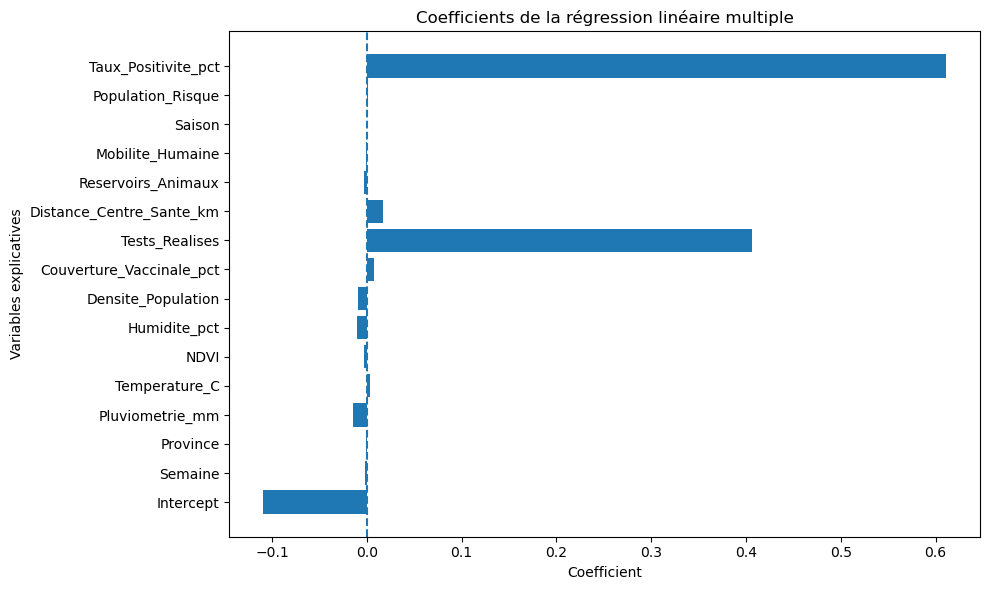

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    coef_df['Variable'],
    coef_df['Coefficient']
)

plt.axvline(
    x=0,
    linestyle='--'
)

plt.xlabel('Coefficient')
plt.ylabel('Variables explicatives')
plt.title('Coefficients de la régression linéaire multiple')

plt.tight_layout()

plt.savefig(
    "E:/Documents/A/bakwetu/coccinelle/MASG_M2/Programme_de_cours/IA & Ecologie de maladie (Data sciences)/git_cours/TP_RM/graphique_coefficients.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()